In [ ]:
import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    StandardScaler,
)
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import StackingRegressor

from lightgbm import LGBMRegressor

import optuna
from optuna.integration import OptunaSearchCV
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler


try:
    from optuna.distributions import (
        IntDistribution,
        FloatDistribution,
        CategoricalDistribution,
    )
except ImportError:
    from optuna.distributions import IntUniformDistribution as IntDistribution, \
                                        FloatUniformDistribution as FloatDistribution
    from optuna.distributions import CategoricalDistribution


In [54]:
train_df = pd.read_csv('train.csv')
print(train_df.shape)
train_df.head(5)

test_df = pd.read_csv('test.csv')
print(test_df.shape)
test_df.head(5)


TARGET = 'y'
train_df['__is_train__'] = 1
test_df ['__is_train__'] = 0
test_df[TARGET] = np.nan
df = pd.concat([train_df, test_df], ignore_index=True)
df.drop(columns=['w'], inplace=True)

(4500, 13)
(2834, 11)


In [55]:
print(df.shape)
df.head()

(7334, 13)


,y,square_meters,contract_type,availability,description,other_features,conditions,floor,elevator,energy_efficiency_class,condominium_fees,zone,__is_train__
0,3000.0,110,rent,NaN,"4 (2 bedrooms, 2 others), 1 bathroom - one or ...",kitchen | balcony | terrace | furnished | cell...,excellent,1,yes,e,500.0,quadronno - crocetta,1
1,2200.0,111,rent,available,"3 (2 bedrooms, 1 other), 1 bathroom, kitchen d...",electric gate | optic fiber | alarm system | c...,excellent,6,yes,e,400.0,farini,1
2,2500.0,85,rent | 4+4,NaN,"3 (2 bedrooms, 1 other), 2 bathrooms, open kit...",internal exposure | balcony | full day concier...,good condition,4,yes,g,250.0,palestro,1
3,1250.0,40,rent,available,"1 room, 1 bathroom, kitchen nook",optic fiber | security door | internal exposur...,excellent,2,yes,e,90.0,repubblica,1
4,4200.0,170,rent | open,available,"4 (2 bedrooms, 2 others), 3 bathrooms, kitchen...",fireplace | optic fiber | security door | balc...,excellent,4,yes,g,833.0,morgagni,1



# Exploratory Analysis

In [56]:
## Dummy
df.contract_type.value_counts()

open_terms    = ['rent', 'rent | open']
fixed_terms   = ['rent | 4+4', 'rent | 3+2', 'rent | 6+6']
rare_terms    = ['rent | transitory', 'rent | students (6 - 36 months)']

df['contract_group'] = 'rent_other'

df.loc[df['contract_type'].isin(open_terms),  'contract_group'] = 'rent_open'
df.loc[df['contract_type'].isin(fixed_terms), 'contract_group'] = 'rent_fixed'

print(df['contract_group'].value_counts())

contract_group
rent_fixed    3127
rent_open     2338
rent_other    1869
Name: count, dtype: int64


In [57]:
df.availability.value_counts()

# drop column availability
df.drop(columns=['availability', 'contract_type'], inplace=True)
df.shape

(7334, 12)

In [58]:
df.conditions.value_counts()

conditions
excellent         5178
good condition    1639
new                329
Name: count, dtype: int64

In [59]:
df.floor.value_counts()

floor
1                1694
2                1384
3                1221
4                 872
5                 589
Ground floor      471
Mezzanine         418
6                 320
7                 176
8                 112
Semi-basement      45
9                  25
Name: count, dtype: int64

In [60]:
def floor_group(x):
    if x == 'Semi-basement' or x == 'Mezzanine':
        return 'basement'
    if x == 'Ground floor':
        return 'ground'
    try:
        n = int(x)
    except (TypeError, ValueError):
        return 'other'
    if 1 <= n <= 2:
        return 'low (1–2)'
    if 3 <= n <= 4:
        return 'low (3–4)'
    elif 5 <= n <= 6:
        return 'mid (5–6)'
    else:
        return 'high (7+)'

df['floor_group'] = df['floor'].apply(floor_group)
df.drop(columns=['floor'], inplace=True)

print(df['floor_group'].value_counts())

floor_group
low (1–2)    3078
low (3–4)    2093
mid (5–6)     909
ground        471
basement      463
high (7+)     313
other           7
Name: count, dtype: int64


In [61]:
mean_y_by_floor = df.groupby('floor_group')['y'].mean()
print(mean_y_by_floor)

floor_group
basement     1536.593857
ground       1527.710247
high (7+)    1956.641711
low (1–2)    2020.386737
low (3–4)    2114.627052
mid (5–6)    2036.952381
other        1716.333333
Name: y, dtype: float64


In [62]:
df.loc[df['floor_group'] == 'other', 'floor_group'] = np.nan

In [63]:
df.elevator.value_counts()

elevator
yes    5270
no     2064
Name: count, dtype: int64

In [64]:
df.energy_efficiency_class.value_counts()

energy_efficiency_class
g    2133
f    1253
c    1057
e     943
d     626
a     498
b     216
,       2
Name: count, dtype: int64

In [65]:
df['energy_efficiency_class'] = (
    df['energy_efficiency_class']
      .replace({',' : np.nan})
)

## Imputation and making dummies

In [66]:
df.isna().sum()

y                          2834
square_meters                 0
description                   0
other_features               12
conditions                  188
elevator                      0
energy_efficiency_class     608
condominium_fees            321
zone                          0
__is_train__                  0
contract_group                0
floor_group                   7
dtype: int64

In [ ]:
num_cols     = df.select_dtypes(include='number').columns.tolist()
cat_cols     = df.select_dtypes(include='object').columns.tolist()

X_num = df[num_cols].to_numpy()

knn = KNNImputer(n_neighbors=5, weights='distance')
X_num_imputed = knn.fit_transform(X_num)

df[num_cols] = X_num_imputed

for col in cat_cols:
    mode_val = df[col].mode(dropna=True)[0]
    df[col].fillna(mode_val, inplace=True)

In [68]:
dummy_cols = [
    'contract_group',
    'conditions',
    'floor_group',
    'elevator',
    'energy_efficiency_class'
]

dummies = pd.get_dummies(
    df[dummy_cols],
    prefix=dummy_cols,
    prefix_sep='__',
    drop_first=True,
    dtype='uint8'
)


df = pd.concat([df.drop(columns=dummy_cols), dummies], axis=1)
print(f"Added {dummies.shape[1]} dummy columns; "
      f"train_df is now {df.shape[0]} × {df.shape[1]}.")

Added 16 dummy columns; train_df is now 7334 × 23.


## Geographical info

In [69]:
cache_fp = Path("./milan_zone_geocodes.json")
if cache_fp.exists():
    geo_cache = json.loads(cache_fp.read_text())
else:
    geo_cache = {}

geolocator = Nominatim(user_agent="milan_zone_geocoder")
geocode    = RateLimiter(geolocator.geocode, min_delay_seconds=1)

def try_geocode(q: str):
    """Return (lat, lon) or None."""
    if not q:
        return None
    loc = geocode(f"{q}, Milan, Italy")
    return (loc.latitude, loc.longitude) if loc else None

def smart_geocode(zone: str):
    z = str(zone).strip().lower()
    hit = try_geocode(z)
    if hit:
        return hit
    if " - " in z:
        hit = try_geocode(z.split(" - ")[0].strip())
        if hit:
            return hit
    hit = try_geocode(z.split()[0])
    if hit:
        return hit
    manual = {
        "monte rosa - lotto": (45.4783, 9.1470),
        "pezzotti - meda":    (45.4426, 9.1996),
    }
    return manual.get(z)

zones = df["zone"].dropna().unique().tolist()
for z in tqdm(zones, desc="geocoding zones"):
    key = str(z).strip().lower()
    if key in geo_cache:
        continue
    hit = smart_geocode(z)
    if hit:
        lat, lon = hit
        geo_cache[key] = {"lat": lat, "lon": lon}
    else:
        print("Still not found:", z)

cache_fp.write_text(json.dumps(geo_cache, indent=2))

DUOMO_LAT, DUOMO_LON = 45.464211, 9.191383
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  
    φ1, φ2 = np.radians(lat1), np.radians(lat2)
    Δφ     = np.radians(lat2 - lat1)
    Δλ     = np.radians(lon2 - lon1)
    a = np.sin(Δφ/2)**2 + np.cos(φ1)*np.cos(φ2)*np.sin(Δλ/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def zone_distance(z):
    if pd.isna(z):
        return np.nan
    key = str(z).strip().lower()
    info = geo_cache.get(key)
    if info is None:
        return np.nan
    return haversine(info["lat"], info["lon"], DUOMO_LAT, DUOMO_LON)

df["zone_dist_duomo_km"] = df["zone"].apply(zone_distance)
print(df["zone_dist_duomo_km"].describe())

geocoding zones: 100%|██████████| 132/132 [00:00<?, ?it/s]

count    7334.000000
mean        3.666381
std         3.439173
min         0.220710
25%         1.683200
50%         2.983659
75%         4.190778
max        26.767316
Name: zone_dist_duomo_km, dtype: float64


In [70]:
train_mask    = df['__is_train__'] == 1
global_median = df.loc[train_mask, 'y'].median()

zone_median = (
    df.loc[train_mask]
      .groupby('zone')['y']
      .median()
)

df['zone_te'] = df['zone'].map(zone_median).fillna(global_median)

df.drop(columns=['zone'], inplace=True)

## Processing text features

In [71]:
df['other_features']

features = (
    df['other_features']
      .str.lower()
      .str.split(r'\s*\|\s*')
      .explode()
      .dropna()
)

feature_counts = features.value_counts().reset_index()
feature_counts.columns = ['feature', 'count']

print(feature_counts.to_string())


                                                                 feature  count
0                                                              furnished   5508
1                                                          security door   5356
2                                                  centralized tv system   4714
3                                                            optic fiber   4485
4                                                                balcony   3642
5                                                     full day concierge   2795
6                                                       video entryphone   2385
7                                                                 closet   2146
8                                                          electric gate   2038
9                                                      external exposure   1949
10                                                         shared garden   1921
11                                      

In [72]:
tokens = (
    df['other_features']
      .str.lower()
      .fillna('')
      .str.split(r'\s*\|\s*')      
      .explode()
      .str.strip()
      .replace('', pd.NA)
      .dropna()
)

re_balcony       = re.compile(r'\b\d+\s*balconi[ey]\b|\bbalcony\b')
re_glazing       = re.compile(r'window frames in (single|double|triple) glass')
re_frame_mat     = re.compile(r'window frames in .*?/\s*(wood|pvc|metal)')
re_exposure      = re.compile(r'exposure (?P<dirs>[nesw](?:\s*,\s*[nesw])*)')
dir_map          = {'n': 'north', 'e': 'east', 's': 'south', 'w': 'west'}

cols = [
    'furnished_full', 'furnished_partial',
    'security_basic', 'security_gatephone',
    'tv_centralized', 'optic_fiber',
    'concierge_full', 'concierge_half',

    'balcony', 'terrace', 'garden_private', 'garden_shared',
    'pool', 'tennis_court',

    'cellar', 'attic', 'closet', 'kitchen', 'reception', 'tavern',
    'fireplace', 'hydromassage',

    'exposure_internal', 'exposure_external', 'double_exposure',
    'exp_north', 'exp_south', 'exp_east', 'exp_west',

    'glazing_single', 'glazing_double', 'glazing_triple',
    'frame_wood', 'frame_pvc', 'frame_metal',
]
df[cols] = False        

for tok in tokens.unique():      
    mask = df['other_features'].str.contains(re.escape(tok), case=False, na=False)

    if   'security door'     in tok or 'alarm system'     in tok: df.loc[mask, 'security_basic']    = True
    elif 'electric gate'     in tok or 'video entryphone' in tok: df.loc[mask, 'security_gatephone'] = True
    elif 'centralized tv'    in tok or 'satellite'        in tok or 'single tv' in tok:
         df.loc[mask, 'tv_centralized'] = True
    elif tok == 'optic fiber':        df.loc[mask, 'optic_fiber']     = True
    elif tok == 'full day concierge': df.loc[mask, 'concierge_full']  = True
    elif 'half-day concierge' in tok: df.loc[mask, 'concierge_half']  = True
    elif tok == 'private garden':     df.loc[mask, 'garden_private']  = True
    elif tok == 'shared garden':      df.loc[mask, 'garden_shared']   = True
    elif tok in ('pool', 'tennis court', 'cellar', 'attic',
                 'closet', 'kitchen', 'reception', 'tavern',
                 'fireplace', 'hydromassage'):
         df.loc[mask, tok.replace(' ', '_')] = True

    elif tok == 'furnished':          df.loc[mask, 'furnished_full'] = True
    elif 'partially furnished' in tok or 'only kitchen furnished' in tok:
         df.loc[mask, 'furnished_partial'] = True

    elif re_balcony.search(tok):      df.loc[mask, 'balcony'] = True
    elif 'terrace' in tok:            df.loc[mask, 'terrace'] = True

    m = re_glazing.search(tok)
    if m:
        df.loc[mask, f"glazing_{m.group(1)}"] = True

    m = re_frame_mat.search(tok)
    if m:
        df.loc[mask, f"frame_{m.group(1)}"] = True

    if 'internal exposure' in tok: df.loc[mask, 'exposure_internal'] = True
    elif 'external exposure' in tok: df.loc[mask, 'exposure_external'] = True
    elif 'double exposure'  in tok: df.loc[mask, 'double_exposure']   = True

    m = re_exposure.search(tok)
    if m:
        for d in m.group('dirs').split(','):
            df.loc[mask, f"exp_{dir_map[d.strip()]}"] = True

In [73]:
df.drop(columns=['other_features'], inplace=True)

In [74]:
df['description']

0       4 (2 bedrooms, 2 others), 1 bathroom - one or ...
1       3 (2 bedrooms, 1 other), 1 bathroom, kitchen d...
2       3 (2 bedrooms, 1 other), 2 bathrooms, open kit...
3                        1 room, 1 bathroom, kitchen nook
4       4 (2 bedrooms, 2 others), 3 bathrooms, kitchen...
                              ...                        
7329                  1 bedroom, 1 bathroom, open kitchen
7330    3 (2 bedrooms, 1 other), 1 bathroom, open kitchen
7331                  1 bedroom, 1 bathroom, open kitchen
7332     2 (1 bedroom, 1 other), 1 bathroom, open kitchen
7333     3 (1 bedroom, 2 others), 1 bathroom, kitchenette
Name: description, Length: 7334, dtype: object

In [75]:
## Pricessing descriptions
df['description']

descs = df['description'].dropna().str.lower()

tokens = descs\
    .str.replace(r'\d+',     '', regex=True)\
    .str.replace(r'[^a-z\s]', '', regex=True)\
    .str.split()

all_toks = [tok for sub in tokens for tok in sub]
counts  = Counter(all_toks)

df_words = (
    pd.DataFrame(counts.most_common(50), columns=['word','count'])
)
print(df_words)


             word  count
0         kitchen   5951
1           other   5795
2        bathroom   5503
3         bedroom   4365
4            open   2933
5        bedrooms   2639
6           diner   1956
7       bathrooms   1773
8            nook    735
9     kitchenette    459
10         others    374
11  semihabitable    327
12           room    273
13          rooms     57
14            one     22
15             or     22
16           more     22
17       suitable     22
18            for     22
19       disabled     22
20         people     22


In [76]:
KITCHEN_PATTERNS = {
    r'kitchen\s*-?\s*diner':   'diner',
    r'open\s+kitchen':         'open',
    r'kitchen\s+nook':         'nook',
    r'kitchenette':            'kitchenette',
}

KITCHEN_REGEXES = [(re.compile(pat), label) for pat, label in KITCHEN_PATTERNS.items()]

INT       = r'(\d+)\s*'          
ROOMS_RE  = re.compile(INT + r'rooms?\b')          
BED_RE    = re.compile(INT + r'bedrooms?\b')      
BATH_RE   = re.compile(INT + r'bathrooms?\b')     
OTHER_RE  = re.compile(INT + r'others?\b')         

def parse_description(text: str) -> pd.Series:
    if pd.isna(text):
        return pd.Series({
            'rooms_total':  0,
            'bedrooms':     0,
            'rooms_other':  0,
            'bathrooms':    0,
            'kitchen_type': 'unknown'
        })

    txt = text.lower()

    def _first_int(regex):
        m = regex.search(txt)
        return int(m.group(1)) if m else None

    rooms_total = _first_int(ROOMS_RE)
    bedrooms    = _first_int(BED_RE)  or 0
    rooms_other = _first_int(OTHER_RE) or 0
    bathrooms   = _first_int(BATH_RE) or 0

    if rooms_total is None:
        parts = bedrooms + rooms_other
        rooms_total = parts if parts else 0

    kitchen_type = 'unknown'  
    for rx, label in KITCHEN_REGEXES:
        if rx.search(txt):
            kitchen_type = label
            break
    if kitchen_type == 'unknown' and 'kitchen' in txt:
        kitchen_type = 'standard'

    return pd.Series({
        'rooms_total':  rooms_total,
        'bedrooms':     bedrooms,
        'rooms_other':  rooms_other,
        'bathrooms':    bathrooms,
        'kitchen_type': kitchen_type
    })

parsed = df['description'].apply(parse_description)
df = pd.concat([df, parsed], axis=1).drop(columns=['description'])

df['kitchen_type'] = pd.Categorical(
    df['kitchen_type'],
    categories=['unknown', 'standard', 'open', 'diner', 'nook', 'kitchenette'],
    ordered=True
)

print(df[['rooms_total', 'bedrooms', 'rooms_other', 'bathrooms', 'kitchen_type']].head())

   rooms_total  bedrooms  rooms_other  bathrooms kitchen_type
0            4         2            2          1      unknown
1            3         2            1          1        diner
2            3         2            1          2         open
3            1         0            0          1         nook
4            4         2            2          3        diner


## Numerical Columns

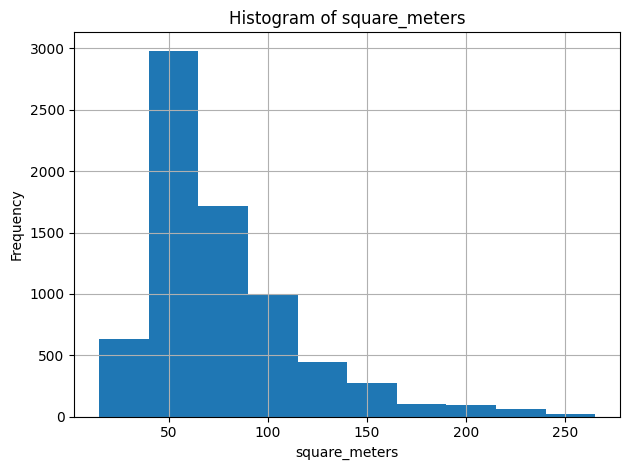

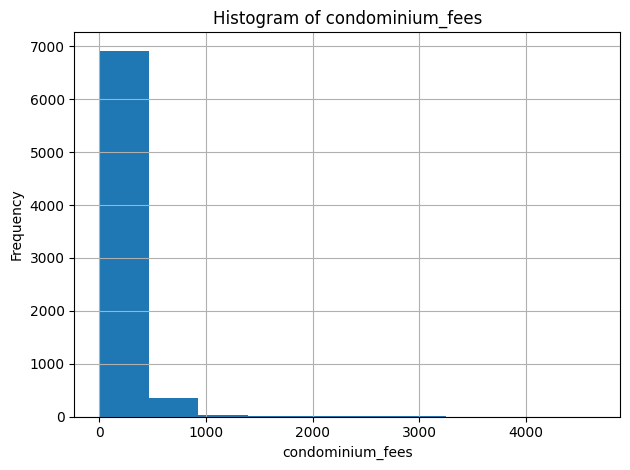

count    7334.000000
mean      189.040609
std       195.981212
min         0.000000
25%        80.000000
50%       150.000000
75%       250.000000
max      4650.000000
Name: condominium_fees, dtype: float64

In [77]:
## Numerical Columns
numeric_cols = ['square_meters', 'condominium_fees']

for col in numeric_cols:
    plt.figure()
    df[col].dropna().hist()
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

df.condominium_fees.describe()

#for col in ['square_meters', 'condominium_fees']:
#    df[f'{col}_log'] = np.log1p(df[col])

#df.drop(columns=['square_meters', 'condominium_fees'], inplace=True)

## Create new columns

In [78]:
def engineer(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    def s(col, default=0):
        return df[col] if col in df.columns else pd.Series(default, index=df.index)

    df["area_per_room"]   = df["square_meters"] / df["rooms_total"].replace(0, np.nan)
    df["bath_per_room"]   = df["bathrooms"]     / df["rooms_total"].replace(0, np.nan)
    df["rooms_per_bath"]  = df["rooms_total"]   / df["bathrooms"].replace(0, np.nan)
    df["bedrooms_share"]  = df["bedrooms"]      / df["rooms_total"].replace(0, np.nan)
    df["condo_fee_m2"]    = df["condominium_fees"] / df["square_meters"].replace(0, np.nan)

    df["high_floor_flag"] = (
        s("floor_group__mid (5–6)") | s("floor_group__high (7+)")
    ).astype("int8")
    df["high_floor_no_elev"] = (
        df["high_floor_flag"] & (~s("elevator__yes").astype(bool))
    ).astype("int8")

    orient_cols = ["exp_north", "exp_south", "exp_east", "exp_west"]
    df["orientation_count"] = df[orient_cols].sum(axis=1)

    df["glazing_score"] = (
          s("glazing_single")  * 1
        + s("glazing_double")  * 2
        + s("glazing_triple")  * 3
    ).astype("int8")

    energy_map = {"a": 7, "b": 6, "c": 5, "d": 4, "e": 3, "f": 2, "g": 1}
    df["energy_score"] = 0
    for k, v in energy_map.items():
        col = f"energy_efficiency_class__{k}"
        if col in df.columns:
            df.loc[df[col] == 1, "energy_score"] = v
    df["energy_score"] = df["energy_score"].astype("int8")

    standard_amen = [
        "tv_centralized", "furnished_partial", "security_basic",
        "cellar", "closet", "security_gatephone", "concierge_half",
        "kitchen", "balcony", "internal_exposure", "optic_fiber",
    ]
    luxury_amen = [
        "terrace", "garden_private", "garden_shared", "pool", "tennis_court",
        "double_exposure", "furnished_full", "concierge_full", "hydromassage",
        "tavern", "fireplace", "attic",
    ]
    df["amenity_count"]        = df[[c for c in standard_amen if c in df]].sum(axis=1)
    df["luxury_amenity_count"] = df[[c for c in luxury_amen   if c in df]].sum(axis=1)

    df["central_flag"]        = (df["zone_dist_duomo_km"] < 2).astype("int8")
    df["centr_area_interact"] = df["zone_te"] * df["square_meters"]

    for col in ["square_meters", "condominium_fees", "zone_dist_duomo_km"]:
        df[f"log1p_{col}"] = np.log1p(df[col])

    kitchen_order = ['unknown', 'standard', 'open', 'diner', 'nook', 'kitchenette']
    if "kitchen_type" in df.columns:
        df["kitchen_type_ord"] = (
            df["kitchen_type"]
              .cat.set_categories(kitchen_order)
              .cat.codes
              .astype("int8")
        )

    bool_cols = df.select_dtypes("bool").columns
    df[bool_cols] = df[bool_cols].astype("int8")

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df
df_eng = engineer(df)

In [79]:
freq = df_eng['kitchen_type'].value_counts(normalize=True)
df_eng['kitchen_type_freq'] = df_eng['kitchen_type'].map(freq).astype('float32')

In [80]:
df_eng.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7334 entries, 0 to 7333
Data columns (total 81 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   y                           7334 non-null   float64 
 1   square_meters               7334 non-null   float64 
 2   condominium_fees            7334 non-null   float64 
 3   __is_train__                7334 non-null   float64 
 4   contract_group__rent_open   7334 non-null   uint8   
 5   contract_group__rent_other  7334 non-null   uint8   
 6   conditions__good condition  7334 non-null   uint8   
 7   conditions__new             7334 non-null   uint8   
 8   floor_group__ground         7334 non-null   uint8   
 9   floor_group__high (7+)      7334 non-null   uint8   
 10  floor_group__low (1–2)      7334 non-null   uint8   
 11  floor_group__low (3–4)      7334 non-null   uint8   
 12  floor_group__mid (5–6)      7334 non-null   uint8   
 13  elevator__yes     

# Check

In [81]:
df_eng.shape

(7334, 81)

glazing_single                0.000000
tennis_court                  0.002318
tavern                        0.004091
exp_west                      0.008181
pool                          0.008999
hydromassage                  0.012953
high_floor_no_elev            0.015544
exp_east                      0.017998
fireplace                     0.018680
attic                         0.019226
exp_north                     0.021271
reception                     0.023180
garden_private                0.025907
exp_south                     0.026179
energy_efficiency_class__b    0.029452
glazing_triple                0.037906
floor_group__high (7+)        0.042678
conditions__new               0.044860
floor_group__ground           0.064221
orientation_count             0.073630
dtype: float64
floor_group__low (1–2)    0.420644
security_gatephone        0.422962
balcony                   0.496728
glazing_double            0.537769
optic_fiber               0.611535
__is_train__              0.61

<Axes: >

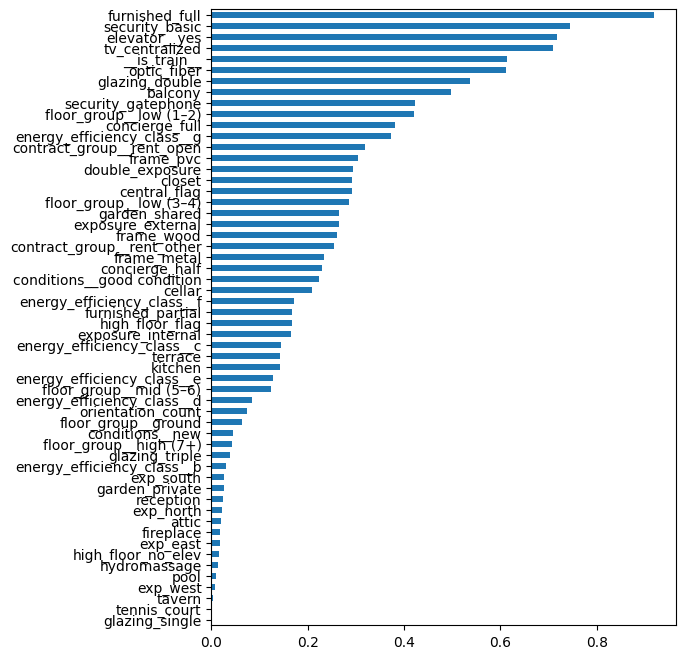

In [82]:
binary_cols = [c for c in df_eng.columns 
               if df_eng[c].dropna().isin([0,1]).all()]

imbalance = df_eng[binary_cols].mean().sort_values()

print(imbalance.head(20))   
print(imbalance.tail(10))   

imbalance.plot.barh(figsize=(6,8))


In [83]:
zero_var = imbalance[imbalance == 0].index
df_tree = df_eng.drop(columns=zero_var)

In [84]:
df_tree.shape

(7334, 80)

In [85]:
from scipy.stats import skew

cont_cols = df_tree.select_dtypes(include='float64').columns.difference(['y','__is_train__'])
skews = skew(df_tree[cont_cols].fillna(0), nan_policy='omit')
skewness = pd.Series(skews, index=cont_cols).abs().sort_values(ascending=False)
print(skewness.head(10)) 

rooms_per_bath            8.814704
condo_fee_m2              5.731847
condominium_fees          5.601518
centr_area_interact       4.820478
zone_dist_duomo_km        3.791036
zone_te                   3.660016
area_per_room             2.946417
square_meters             1.652033
log1p_condominium_fees    1.407395
bath_per_room             0.954352
dtype: float64


In [86]:
def winsorize(s, p=0.995):
    lo, hi = s.quantile(1-p), s.quantile(p)
    return s.clip(lo, hi)

skew_cols = [
    ('rooms_per_bath',      True),   
    ('bath_per_room',       True),
    ('area_per_room',       False),
    ('condo_fee_m2',        False),
    ('centr_area_interact', False),
    ('zone_te',             False),
]

for col, clip_first in skew_cols:
    if col not in df_tree:         
        continue
    x = df_tree[col]
    if clip_first:
        x = winsorize(x)       
    df_tree[f'log1p_{col}'] = np.log1p(x)

In [87]:
df_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7334 entries, 0 to 7333
Data columns (total 86 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   y                           7334 non-null   float64 
 1   square_meters               7334 non-null   float64 
 2   condominium_fees            7334 non-null   float64 
 3   __is_train__                7334 non-null   float64 
 4   contract_group__rent_open   7334 non-null   uint8   
 5   contract_group__rent_other  7334 non-null   uint8   
 6   conditions__good condition  7334 non-null   uint8   
 7   conditions__new             7334 non-null   uint8   
 8   floor_group__ground         7334 non-null   uint8   
 9   floor_group__high (7+)      7334 non-null   uint8   
 10  floor_group__low (1–2)      7334 non-null   uint8   
 11  floor_group__low (3–4)      7334 non-null   uint8   
 12  floor_group__mid (5–6)      7334 non-null   uint8   
 13  elevator__yes     

In [88]:
raw_ratios = [
    "area_per_room",
    "bath_per_room",
    "rooms_per_bath",
    "condo_fee_m2",
    "bedrooms_share",
    "centr_area_interact",
]

exp = ['exp_north', 'exp_south', 'exp_east', 'exp_west']
floor = ['floor_group__mid (5–6)','floor_group__high (7+)']
energy_dummies = [c for c in df_tree.columns if c.startswith("energy_efficiency_class__")]

glazing_dummies = ["glazing_double", "glazing_triple", 'kitchen_type']

to_drop = raw_ratios + energy_dummies + glazing_dummies + exp + floor

print(f"Dropping {len(to_drop)} columns:")
print(to_drop)

df_pruned = df_tree.drop(columns=to_drop)

Dropping 21 columns:
['area_per_room', 'bath_per_room', 'rooms_per_bath', 'condo_fee_m2', 'bedrooms_share', 'centr_area_interact', 'energy_efficiency_class__b', 'energy_efficiency_class__c', 'energy_efficiency_class__d', 'energy_efficiency_class__e', 'energy_efficiency_class__f', 'energy_efficiency_class__g', 'glazing_double', 'glazing_triple', 'kitchen_type', 'exp_north', 'exp_south', 'exp_east', 'exp_west', 'floor_group__mid (5–6)', 'floor_group__high (7+)']


# Prediction

In [89]:
df_pruned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7334 entries, 0 to 7333
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   y                           7334 non-null   float64
 1   square_meters               7334 non-null   float64
 2   condominium_fees            7334 non-null   float64
 3   __is_train__                7334 non-null   float64
 4   contract_group__rent_open   7334 non-null   uint8  
 5   contract_group__rent_other  7334 non-null   uint8  
 6   conditions__good condition  7334 non-null   uint8  
 7   conditions__new             7334 non-null   uint8  
 8   floor_group__ground         7334 non-null   uint8  
 9   floor_group__low (1–2)      7334 non-null   uint8  
 10  floor_group__low (3–4)      7334 non-null   uint8  
 11  elevator__yes               7334 non-null   uint8  
 12  zone_dist_duomo_km          7334 non-null   float64
 13  zone_te                     7334 

In [90]:
TARGET     = "y"
META_COLS  = ["__is_train__"]

df_model   = df_pruned.copy()
is_train   = df_model.pop("__is_train__").astype(bool)
y_all      = df_model.pop("y")

num_dtypes = ["float64", "int64", "int32", "int16"]
bin_dtypes = ["bool", "uint8", "int8"]

NUM = df_model.select_dtypes(include=num_dtypes).columns.tolist()
BIN = df_model.select_dtypes(include=bin_dtypes).columns.tolist()

features = NUM + BIN
print(f"{len(features)} predictors selected")

X_train = df_model.loc[is_train, features]
y_train = y_all[is_train]

X_test  = df_model.loc[~is_train, features]
y_test  = y_all[~is_train]

62 predictors selected


In [91]:
def Int(low, high, step=1, log=False):
    return IntDistribution(low=low, high=high, step=step, log=log)

def Float(low, high, step=None, log=False):
    return FloatDistribution(low=low, high=high, step=step, log=log)

In [92]:
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),  
    ('scale',  StandardScaler())
])

bin_pipeline = Pipeline([                           
    ('impute', SimpleImputer(strategy='constant', fill_value=0))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, NUM),
        ('bin', bin_pipeline, BIN),
],
    remainder='drop',
)

In [ ]:
knn = make_pipeline(
    preprocess,
    KNeighborsRegressor()
)

lgbm = LGBMRegressor(
    objective="regression_l1",
    boosting_type="gbdt",
    random_state=42,
    n_jobs=1,
)

stack = StackingRegressor(
    estimators=[('knn', knn), ('lgbm', lgbm)], 
    final_estimator=ElasticNet(random_state=42, max_iter=10_000),
    cv=4,
    n_jobs=1,
    passthrough=False
)

model = TransformedTargetRegressor(
    regressor=stack,
    func=np.log1p,
    inverse_func=np.expm1
)

# ── Optuna study and search space ─────────────────────────────────────
pruner = optuna.pruners.MedianPruner(
    n_startup_trials=0,   
    n_warmup_steps=0,     
    interval_steps=1      
)
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    pruner=pruner
)

param_distributions = {
    # ── KNN ──────────────────────────────────────────────
    "regressor__knn__kneighborsregressor__n_neighbors": Int(5, 64, log=True),
    "regressor__knn__kneighborsregressor__weights":     CategoricalDistribution(["uniform", "distance"]),
    "regressor__knn__kneighborsregressor__p":           CategoricalDistribution([1, 2]),    
    "regressor__knn__kneighborsregressor__leaf_size":   Int(20, 100),

    # ── LightGBM ────────────────────────────────────────
    "regressor__lgbm__boosting_type":      CategoricalDistribution(["gbdt", "dart"]),
    "regressor__lgbm__n_estimators":       Int(800, 4000, step=50),
    "regressor__lgbm__learning_rate":      Float(0.005, 0.15, log=True),
    "regressor__lgbm__max_depth":          Int(4, 14),
    "regressor__lgbm__num_leaves":         Int(31, 512),
    "regressor__lgbm__min_child_samples":  Int(3, 30),
    "regressor__lgbm__subsample":          Float(0.5, 1.0),
    "regressor__lgbm__colsample_bytree":   Float(0.5, 1.0),
    "regressor__lgbm__reg_alpha":          Float(1e-4, 2.0, log=True),
    "regressor__lgbm__reg_lambda":         Float(1e-4, 2.0, log=True),
    "regressor__lgbm__min_split_gain":     Float(0.0, 0.2),

    # ── Meta-learner (ElasticNet) ───────────────────────
    "regressor__final_estimator__alpha":    Float(1e-6, 10.0, log=True),
    "regressor__final_estimator__l1_ratio": Float(0.0, 1.0),
}

# ── OptunaSearchCV set-up ─────────────────────────────────────────────
optuna_cv = OptunaSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    cv=KFold(n_splits=4, shuffle=True, random_state=42),
    scoring="neg_mean_absolute_error",
    n_trials=500,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    study=study,
    refit=True,
    error_score='raise'
)

# ── Fit search ────────────────────────────────────────────────────────
optuna_cv.fit(X_train, y_train)

print(f"Best CV MAE: {-optuna_cv.best_score_:.4f}\n")
print("Best hyperparameters:")
for k, v in optuna_cv.best_params_.items():
    print(f"  {k}: {v}")

In [ ]:
best_model = optuna_cv.best_estimator_
y_pred = best_model.predict(X_test)

out_path = Path("the_final_hope_2.txt")
np.savetxt(out_path, y_pred, fmt="%.6f")   

print(f"Saved {len(y_pred)} predictions to: {out_path.resolve()}")


✅ Saved 2834 predictions to: C:\Users\alice\OneDrive - Università Commerciale Luigi Bocconi\2024-2025\2nd semster\ML\Data Challenge\the_final_hope.txt
